[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/04_Centro_Masas_Tumor.ipynb)

# 🧬 LAB 4: Localizando un Tumor (Cálculo Integral)

El cálculo de varias variables, y en particular, las **integrales dobles** nos permiten sumar sobre áreas 2D.

**El caso clínico**: disponemos de una imagen de escáner de un corte transversal de tejido. Observamos una masa tumoral de contorno redondeado, modelada como una **superelipse** de orden 4 centrada en $(1, 2)$ cm:

$$\left(\frac{x-1}{0.9}\right)^4 + \left(\frac{y-2}{1.5}\right)^4 \leq 1$$

La densidad de células malignas $\rho(x,y)$ **crece exponencialmente** hacia la esquina superior-derecha del tumor:
$$\rho(x,y) = e^{\,(x-1) + (y-2)} \quad \text{[mg/cm}^2\text{]}$$

¡Nuestra misión es calcular la masa total del tumor y localizar su **centroide exacto**. Encontrar el punto donde si se apunta el láser de radioterapia se conseguirá mayor eficacia y menor daño para el tejido sano.


C:\Users\pablo\AppData\Local\Temp\ipykernel_34876\1214370925.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(); plt.tight_layout(); plt.show()


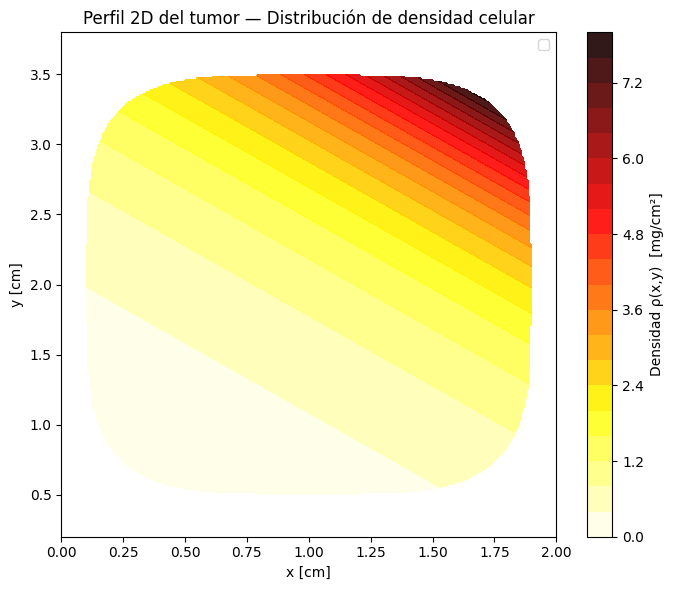

In [19]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad

# Parámetros geométricos del tumor (superelipse, n=4)
CX, CY = 1.0, 2.0   # centro  [cm]
A,  B  = 0.9, 1.5   # semiejes horizontal y vertical [cm]


def dibujar_tumor():
    X, Y = np.meshgrid(np.linspace(0, 2, 300), np.linspace(0.2, 3.8, 300))
    interior = ((X - CX)/A)**4 + ((Y - CY)/B)**4 <= 1
    Z = np.where(interior, np.exp((X - CX) + (Y - CY)), np.nan)

    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(X, Y, Z, levels=20, cmap='hot_r', alpha=0.9)
    plt.colorbar(cf, ax=ax, label='Densidad ρ(x,y)  [mg/cm²]')
    ax.set_xlabel('x [cm]'); ax.set_ylabel('y [cm]')
    ax.set_title('Perfil 2D del tumor — Distribución de densidad celular')
    ax.legend(); plt.tight_layout(); plt.show()

def dibujar_con_centroide(cx, cy, cx_geo=None, cy_geo=None):
    X, Y = np.meshgrid(np.linspace(0, 2, 300), np.linspace(0.2, 3.8, 300))
    Z = np.where(((X - CX)/A)**4 + ((Y - CY)/B)**4 <= 1, np.exp((X - CX) + (Y - CY)), np.nan)

    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(X, Y, Z, levels=20, cmap='hot_r', alpha=0.9)
    plt.colorbar(cf, ax=ax, label='Densidad ρ(x,y)  [mg/cm²]')
    ax.plot(cx, cy, 'c*', markersize=20, label=f'Centroide de masa  ({cx:.2f}, {cy:.2f})')
    if cx_geo is not None:
        ax.plot(cx_geo, cy_geo, 'w^', markersize=12, label=f'Centro geométrico  ({cx_geo:.2f}, {cy_geo:.2f})')
    ax.set_xlabel('x [cm]'); ax.set_ylabel('y [cm]')
    ax.set_title('Centroide de masa vs. centro geométrico')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, framealpha=0.9)
    plt.tight_layout(); plt.show()

dibujar_tumor()


### Herramienta Numérica (`scipy.integrate`)

¿Cómo se pueden aproximar integrales? Para esto usaremos una herramienta en Python estandar: `scipy.integrate.dblquad`.
La herramienta aproxima la integral de `f(y, x)` siendo $x$ exterior y $y$ interior.

$$ M =  \iint_D \rho(x,y) \,dA $$

```python
# Ejemplo de cómo funciona dblquad:
resultado, error = dblquad(f_densidad, limite_x_inf, limite_x_sup, func_y_inf, func_y_sup)
```

In [37]:
def densidad(y, x):     # <- Nota: SciPy siempre requiere primero Y y luego X
    return np.exp((x - CX) + (y - CY))

# Límites de y en función de x (despejando de la superelipse)
def limite_y_inferior(x):
    return CY - B * (1 - ((x - CX)/A)**4)**0.25

def limite_y_superior(x):
    return CY + B * (1 - ((x - CX)/A)**4)**0.25

# Límites de x: los extremos horizontales de la superelipse
x_inf = CX - A   # = 0.1 cm
x_sup = CX + A   # = 1.9 cm

# Calculamos la Masa (M) haciendo la Integral Doble
masa_total, _ = dblquad(densidad, x_inf, x_sup, limite_y_inferior, limite_y_superior)
print(f"La masa total del tumor es: {masa_total:.2f} mg")


La masa total del tumor es: 7.71 mg


### 🛠️ ¡TU TURNO: El centroide completo!

Para apuntar el láser necesitamos **las dos coordenadas** del centroide $(\bar{x}, \bar{y})$:

$$\bar{x} = \frac{1}{M} \iint_D x \cdot \rho(x,y) \,dA \qquad \bar{y} = \frac{1}{M} \iint_D y \cdot \rho(x,y) \,dA$$

**Pasos:**
1. Completa `x_por_densidad(y, x)` y calcula `centroide_x` con `dblquad`
2. Define `y_por_densidad(y, x)` y calcula `centroide_y` 
3. Imprime el resultado: `Centroide del tumor: X=... cm, Y=... cm`

> Antes de calcular: mira el heatmap. ¿Dónde esperas que se se hallará el centroide?


Centroide del tumor: X = 1.22 cm,  Y = 2.59 cm


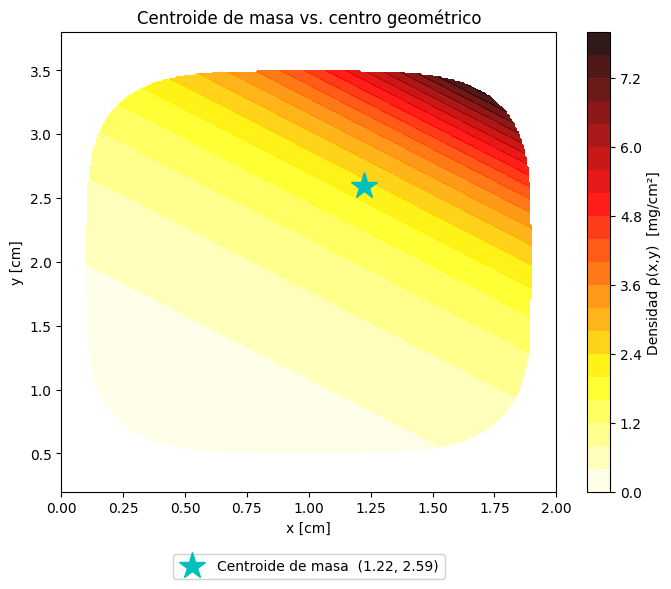

In [21]:
# --- Coordenada X del centroide ---
def x_por_densidad(y, x):
    None    # <--- ¡Tu turno!

momento_x, _ = dblquad(x_por_densidad, x_inf, x_sup, limite_y_inferior, limite_y_superior)
centroide_x = momento_x / masa_total

# --- Coordenada Y del centroide ---
def y_por_densidad(y, x):
    None    # <--- ¡Tu turno!

momento_y, _ = dblquad(y_por_densidad, x_inf, x_sup, limite_y_inferior, limite_y_superior)
centroide_y = momento_y / masa_total

print(f"Centroide del tumor: X = {centroide_x:.2f} cm,  Y = {centroide_y:.2f} cm")
dibujar_con_centroide(centroide_x, centroide_y)


<details>
<summary>👉 <b>Solución paso a paso:</b></summary>

```python
def x_por_densidad(y, x):
    return x * densidad(y, x)

momento_x, _ = dblquad(x_por_densidad, x_inf, x_sup, limite_y_inferior, limite_y_superior)
centroide_x = momento_x / masa_total

def y_por_densidad(y, x):
    return y * densidad(y, x)

momento_y, _ = dblquad(y_por_densidad, x_inf, x_sup, limite_y_inferior, limite_y_superior)
centroide_y = momento_y / masa_total

print(f"Centroide del tumor: X = {centroide_x:.2f} cm,  Y = {centroide_y:.2f} cm")
dibujar_con_centroide(centroide_x, centroide_y)
```
</details>


### BONUS: Exploración interactiva

¿Qué le pasa al centroide si cambiamos la "pendiente" del gradiente exponencial $\rho = e^{b(x-1) + c(y-2)}$?

Mueve los sliders y observa cómo se desplaza el punto de radiación sobre el heatmap.

También observa una simulación de que efecto podría tener el laser sobre el tejido.


In [36]:
# interact(explorar_centroide, b=(0.0, 3.0, 0.1), c=(0.0, 3.0, 0.1))


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def simular_radioterapia(laser_x, laser_y, frames=40):
    """
    Simula el impacto de un láser apuntado a (laser_x, laser_y) 
    sobre el tumor y el tejido circundante.
    """
    # Rejilla del tejido
    X, Y = np.meshgrid(np.linspace(0, 2, 100), np.linspace(0.2, 3.8, 100))
    interior = ((X - CX)/A)**4 + ((Y - CY)/B)**4 <= 1

    # Separar variables para poder medir qué muere
    Z_tumor = np.where(interior, np.exp((X - CX) + (Y - CY)), 0.0)
    Z_sano = np.where(~interior, 1.5, 0.0)  # Densidad base del tejido sano un poco mayor ("más visible")
    Z_total = Z_tumor + Z_sano

    masa_tumor_ini = np.sum(Z_tumor)
    masa_sana_ini = np.sum(Z_sano)

    # --- FIGURA CON DOBLE GRÁFICO ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Simulación Láser apuntado a ({laser_x:.2f}, {laser_y:.2f})', fontsize=14)

    # Plot 1: El Escáner Térmico
    quadmesh = ax1.pcolormesh(X, Y, Z_total, cmap='magma', shading='auto', vmin=0, vmax=np.max(Z_tumor))
    ax1.plot(laser_x, laser_y, 'c+', markersize=15, markeredgewidth=2, label='Objetivo Láser')
    ax1.set_xlabel('x [cm]')
    ax1.set_ylabel('y [cm]')
    ax1.legend(loc='lower left')
    fig.colorbar(quadmesh, ax=ax1, label='Densidad celular (0 = Tejido Muerto)')

    # Plot 2: Gráfica Clínica
    line_tumor, = ax2.plot([], [], 'r-', lw=2.5, label='Tumor Restante')
    line_sano,  = ax2.plot([], [], 'g-', lw=2.5, label='Tejido Sano Restante')
    ax2.set_xlim(0, frames)
    ax2.set_ylim(0, 105)
    ax2.set_xlabel('Tiempo de exposición (frames)')
    ax2.set_ylabel('% de Masa Viva')
    ax2.legend()
    ax2.grid(True)

    # Parámetros del Láser
    sigma = 0.4
    Intensidad_Laser = np.exp(-((X - laser_x)**2 + (Y - laser_y)**2) / (2 * sigma**2))
    tasa_destruccion = 0.5 

    # Variables para guardar progreso de la línea
    hist_frames, pct_tumor, pct_sano = [], [], []

    def actualizar(frame):
        # Calcular supervivencia a este frame (decaimiento exponencial)
        factor_supervivencia = np.exp(-tasa_destruccion * Intensidad_Laser * frame)
        
        Z_tumor_act = Z_tumor * factor_supervivencia
        Z_sano_act = Z_sano * factor_supervivencia
        
        # 1. Actualizar Heatmap
        quadmesh.set_array((Z_tumor_act + Z_sano_act).ravel())
        
        # 2. Actualizar Gráfica
        hist_frames.append(frame)
        pct_tumor.append(100 * np.sum(Z_tumor_act) / masa_tumor_ini)
        pct_sano.append(100 * np.sum(Z_sano_act) / masa_sana_ini)
        
        line_tumor.set_data(hist_frames, pct_tumor)
        line_sano.set_data(hist_frames, pct_sano)
        
        return quadmesh, line_tumor, line_sano

    anim = FuncAnimation(fig, actualizar, frames=frames, interval=120, blit=True)
    plt.close(fig) 
    
    return HTML(anim.to_jshtml())

# ==========================================
#  PRUEBA LA SIMULACIÓN
# Llama a la función pasándole las coordenadas X e Y
# ==========================================

# PRUEBA 1: Disparar al centroide exacto (Descomenta la siguiente línea)
# simular_radioterapia(laser_x=centroide_x, laser_y=centroide_y)



---
## 📚 Referencias

**Gielis, J. (2003).** *A generic geometric transformation that unifies a wide range of natural and abstract shapes.* American Journal of Botany, 90(3), 333–338.  
[→ DOI: 10.3732/ajb.90.3.333](https://doi.org/10.3732/ajb.90.3.333)

**Gatenby, R.A. & Gillies, R.J. (2004).** *Why do cancers have high aerobic glycolysis?* Nature Reviews Cancer, 4(11), 891–899.  
[→ DOI: 10.1038/nrc1478](https://doi.org/10.1038/nrc1478)

**Bentzen, S.M. (2005).** *Theragnostic imaging for radiation oncology: dose-painting by numbers.* The Lancet Oncology, 6(2), 112–117.  
[→ DOI: 10.1016/S1470-2045(05)01737-7](https://doi.org/10.1016/S1470-2045(05)01737-7)

**Virtanen, P. et al. (2020).** *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python.* Nature Methods, 17, 261–272.  
[→ DOI: 10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---

**Pregunta 3.**

*Escribe aquí tu respuesta...*

---